<center>
<h1><b>Information Retrieval : RAG (Retrieval Augmented generation)</b>
</center>


Jusqu’à présent, nous nous sommes concentrés sur l’exécution de tâches de classification et de génération à l’aide de LLM. Pour ces tâches, nos efforts ont porté sur la conception et l’évaluation de prompts qui, à leur tour, s’appuyaient sur les capacités de connaissance et de raisonnement internalisées par les modèles lors du pré‑entraînement (voir la figure ci‑dessous).

Notez que ces tâches (c.-à-d. Text-to-Label ou Text-to-Text) n’avaient pas besoin de contexte supplémentaire sur lequel s’appuyer, puisque ces tâches faisaient partie des étapes d’affinage supervisé (supervised fine-tuning) et de RLHF (Reinforcement Learning from Human Feedback) lors de l’entraînement du modèle. Plus précisément, le contexte que nous avons fourni jusqu’ici au LLM servait uniquement à guider le modèle vers un format de réponse spécifique.

Cependant, il existe des situations importantes où le contexte doit jouer un rôle bien plus déterminant. Par exemple, supposons que nous voulions interroger le LLM afin d’obtenir des informations sur le contenu d’un rapport annuel. Bien que le modèle soit capable de comprendre les instructions dans le prompt, il ignore ce qui s’est produit dans le monde après la date limite (training cutoff date) de son entraînement. En particulier, il est très probable que le rapport annuel n’ait pas été ingéré pendant l’entraînement. Dans ce cas, la sortie du LLM sera, au mieux, peu utile et, au pire, incorrecte (ce que l’on appelle une « hallucination »).

Pour corriger cette limitation majeure, nous devons assembler et injecter un contexte généré de manière dynamique en fonction de l’entrée utilisateur. Le question-réponse sur documents (document-based question answering) est un exemple concret de ce cas d’usage. Un exemple typique est celui où les données stockées par des organisations sont utilisées comme source de contexte pour répondre aux questions posées par les utilisateurs.

Cette idée consistant à récupérer puis injecter dans un prompt un contexte pertinent par rapport à la requête, afin d’enrichir la génération de la réponse, est appelée Retrieval Augmented Generation (RAG).

## **The Building Blocks of RAG**

### **A Workflow for RAG**

La figure ci-dessous illustre les étapes clés impliquées dans la conception d’une solution RAG à l’aide de LLM. Examinons chacune de ces étapes en détail.

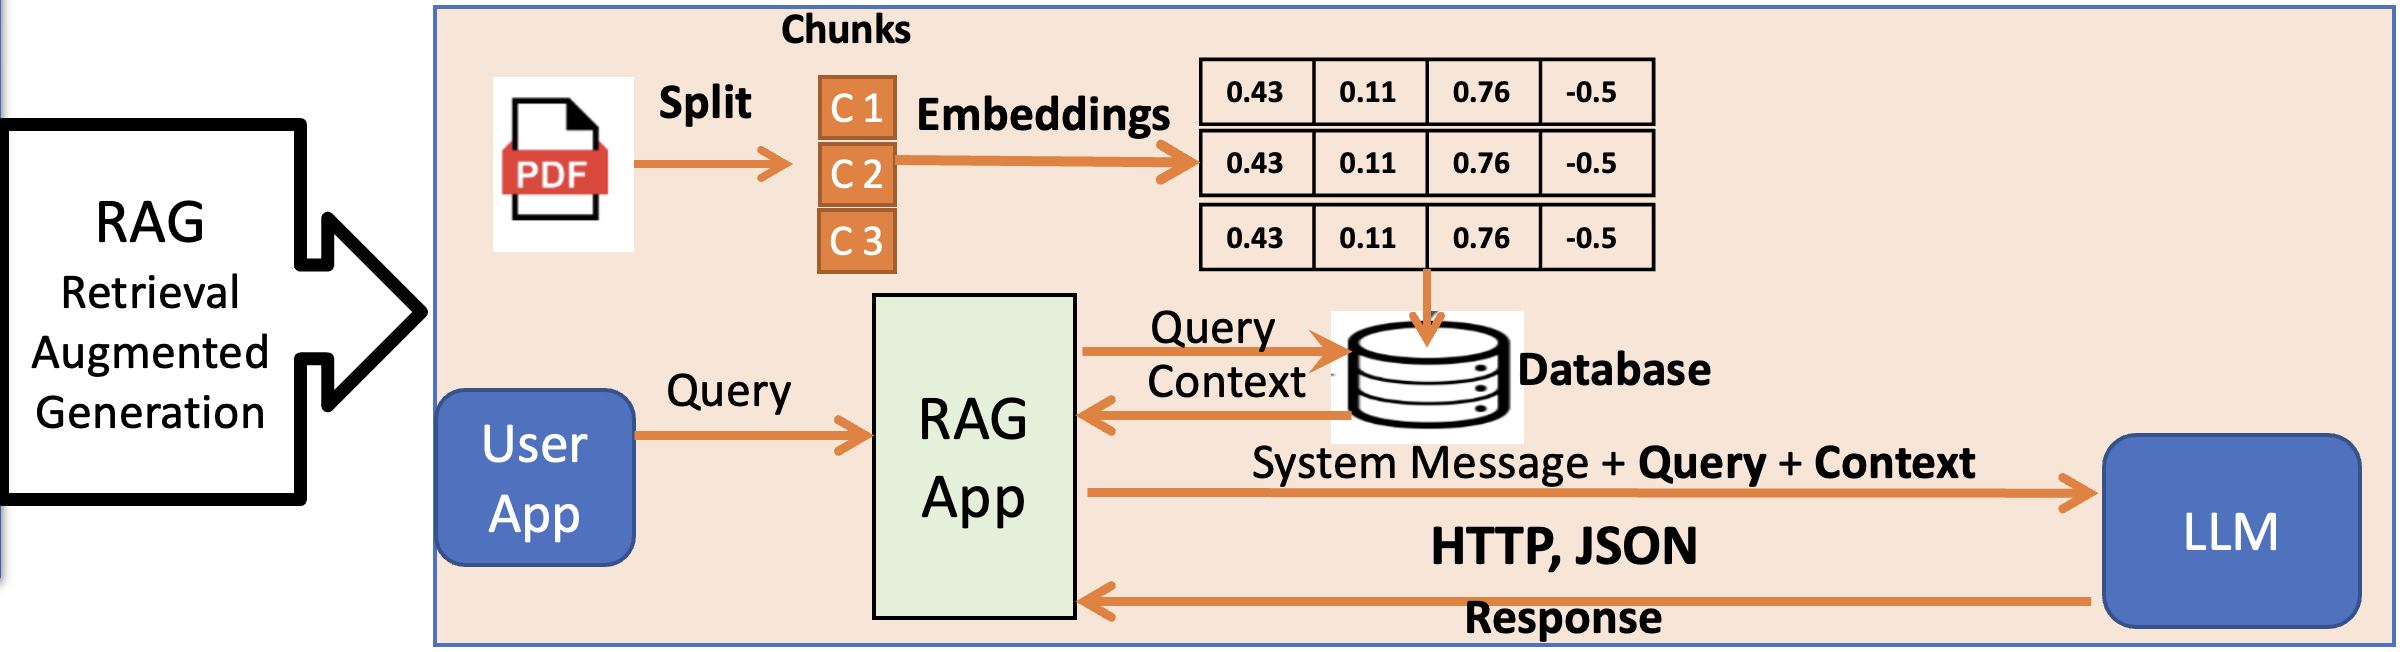

### **Indexation**
Lors de la première étape, nous ingérons les différentes sources de données dans une base de documents. À ce stade, l’objectif est de rassembler toutes les données (quel que soit leur format, par ex. texte, PDF) pertinentes pour le cas d’usage, et les données existent sous leur forme brute, non modifiée. Cependant, étant donné les limitations de la fenêtre de contexte des LLM, nous ne pouvons pas « bourrer » tous les documents de la base comme contexte. Même si nous disposions d’une fenêtre de contexte infinie, le LLM aurait du mal à fournir une réponse cohérente en séparant le signal du bruit. Pour éviter cela, nous devons sélectionner soigneusement les documents qui sont liés à l’entrée utilisateur, afin que le LLM puisse répondre en s’appuyant uniquement sur ce contexte.

Une méthode clé pour faciliter la récupération des documents pertinents consiste à convertir les données brutes ingérées en une représentation vectorielle. Ainsi, nous pouvons comparer la requête (convertie en vecteur) aux vecteurs des documents et ne retenir que les documents similaires à la requête. Ce processus de création d’une représentation vectorielle à partir d’un texte d’entrée s’appelle l’embedding (ou vectorisation) et est réalisé à l’aide de modèles d’embeddings (par ex., SentenceTransformer). Une fois les embeddings créés, ils peuvent être stockés pour une récupération efficace dans des bases de données vectorielles spécialisées telles que Pinecone ou ChromaDB (nous utilisons ChromaDB dans ce notebook).

Bien que les **embeddings** permettent de récupérer un contexte approprié à partir d’une requête, une application plus efficace de la vectorisation consiste à **découper les données brutes en segments plus petits** (*chunks*) avant de les transmettre à un modèle d’embeddings. Deux raisons importantes expliquent pourquoi cela est nécessaire :

- Les modèles d’embeddings sont eux-mêmes des modèles **Transformer** et ont donc des **contraintes de longueur d’entrée**. Tout texte dont la longueur dépasse la longueur d’entrée maximale autorisée par le modèle d’embedding est généralement **tronqué**.
- Le découpage des données en *chunks* facilite un **contrôle fin** sur l’information précise qui peut être injectée comme contexte. Cela aide le modèle à se concentrer uniquement sur l’information **la plus pertinente** pour la requête.

### **Retrieval**

Lors de la deuxième étape, un **prompt** est assemblé de manière dynamique lorsqu’une entrée utilisateur est reçue. Cette entrée utilisateur est convertie en **représentation vectorielle** à l’aide du même modèle que celui utilisé pour les chunks de contexte. Ensuite, une **recherche par similarité** est effectuée sur les chunks vectorisés dans la base de données vectorielle. Les **top-$k$** chunks issus des résultats de recherche sont alors injectés dans le prompt en tant que **contexte**, et le LLM reçoit l’instruction de répondre à la requête utilisateur en s’appuyant **uniquement** sur ce contexte.

Pour faciliter l’**indexation** et la **récupération**, on utilise des abstractions telles que les **chunkers** (découpeurs), les **retrievers** (récupérateurs) et les **readers** (lecteurs), qui s’interfacent respectivement avec la **base de documents**, la **base de données vectorielle** et le **LLM**. Parmi les bibliothèques populaires qui implémentent ces abstractions figurent `langchain` et `llamaindex`.

## **Step 1: Creating a Vector Database (Indexing)**

Nous créons une **base de données vectorielle** en découpant le document d’entrée en chunks, puis en associant à chaque chunk un **vecteur** à l’aide d’un modèle d’embeddings. Le processus global est décrit dans la figure ci-dessous.

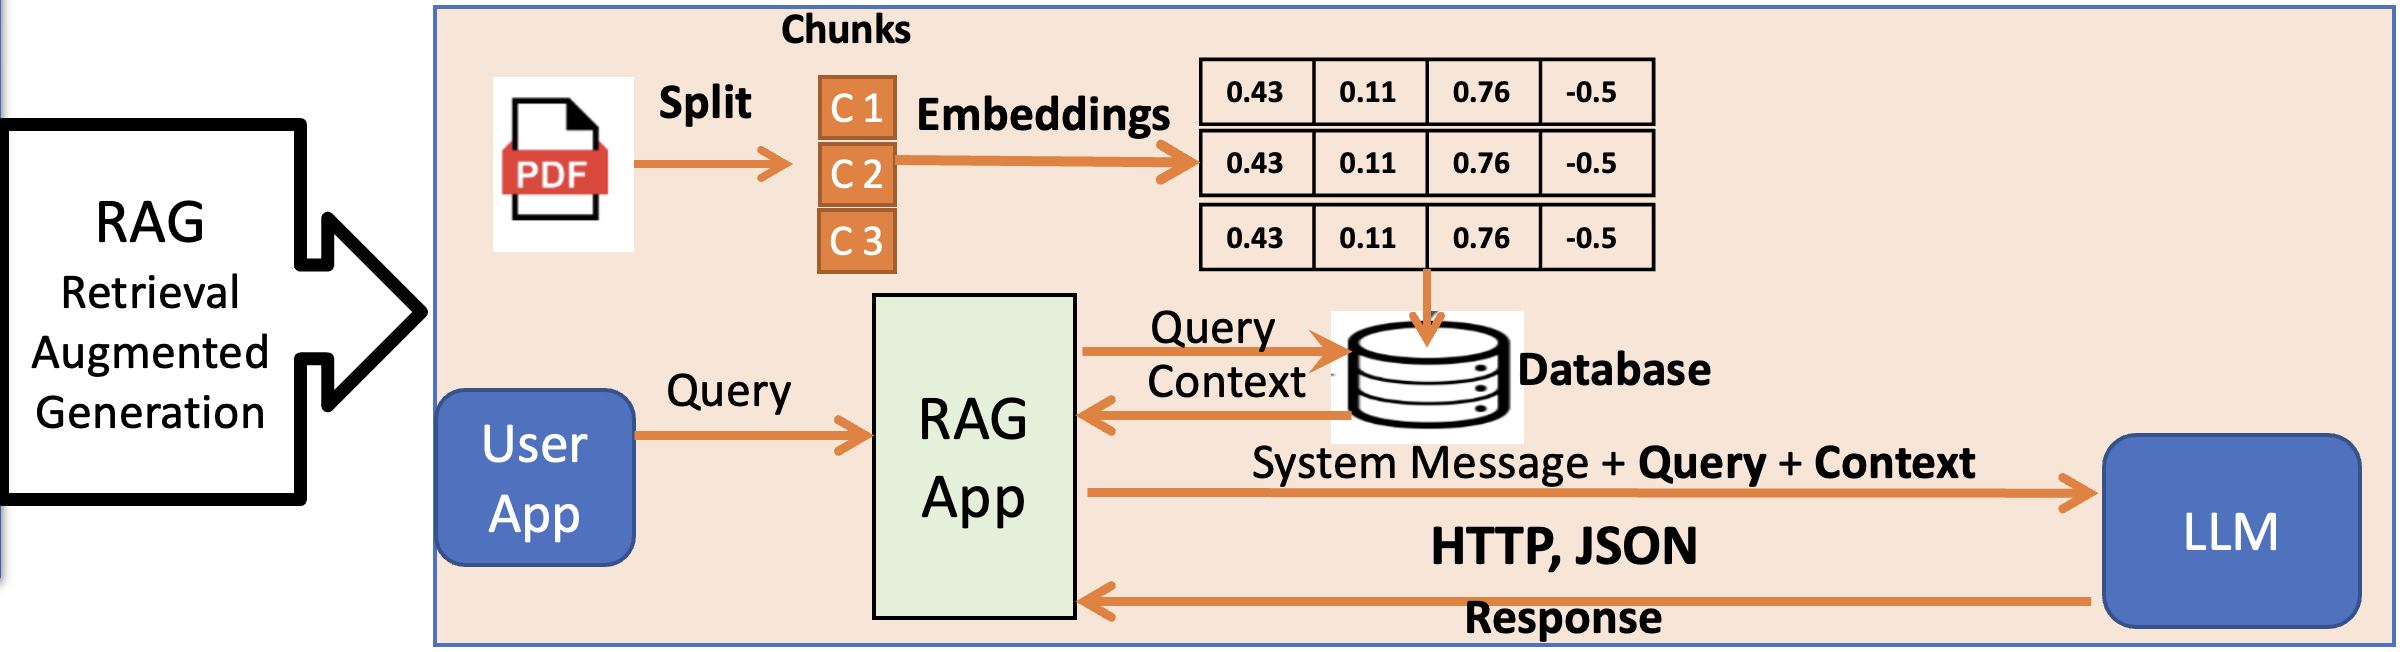

#### **Choosing an embedding model**

Récapitulons d’abord ce que sont les **embeddings** :

- Les embeddings sont un type de **représentation des mots** qui permet à des mots ayant une signification similaire d’avoir une représentation similaire.
- Ils capturent les **propriétés sémantiques** des mots ainsi que leurs **relations** avec d’autres mots.

De bons modèles d’**embeddings** encodent le texte en **représentations vectorielles** qui constituent de bonnes *features* pour les tâches aval des LLM (par ex., dans ce cas, la **récupération**). Cependant, il existe de nombreux modèles d’embeddings parmi lesquels choisir (gratuits comme payants), et ce choix n’est pas toujours évident. De plus, rien ne prouve que les modèles d’embeddings gratuits/open source (par ex., les modèles hébergés sur HuggingFace) soient moins efficaces que les modèles payants (par ex., ceux d’OpenAI).

Une bonne méthode pour choisir un modèle d’embedding consiste à utiliser le [classement des embeddings](https://huggingface.co/spaces/mteb/leaderboard) et à sélectionner un modèle open source performant pour le cas d’usage visé.

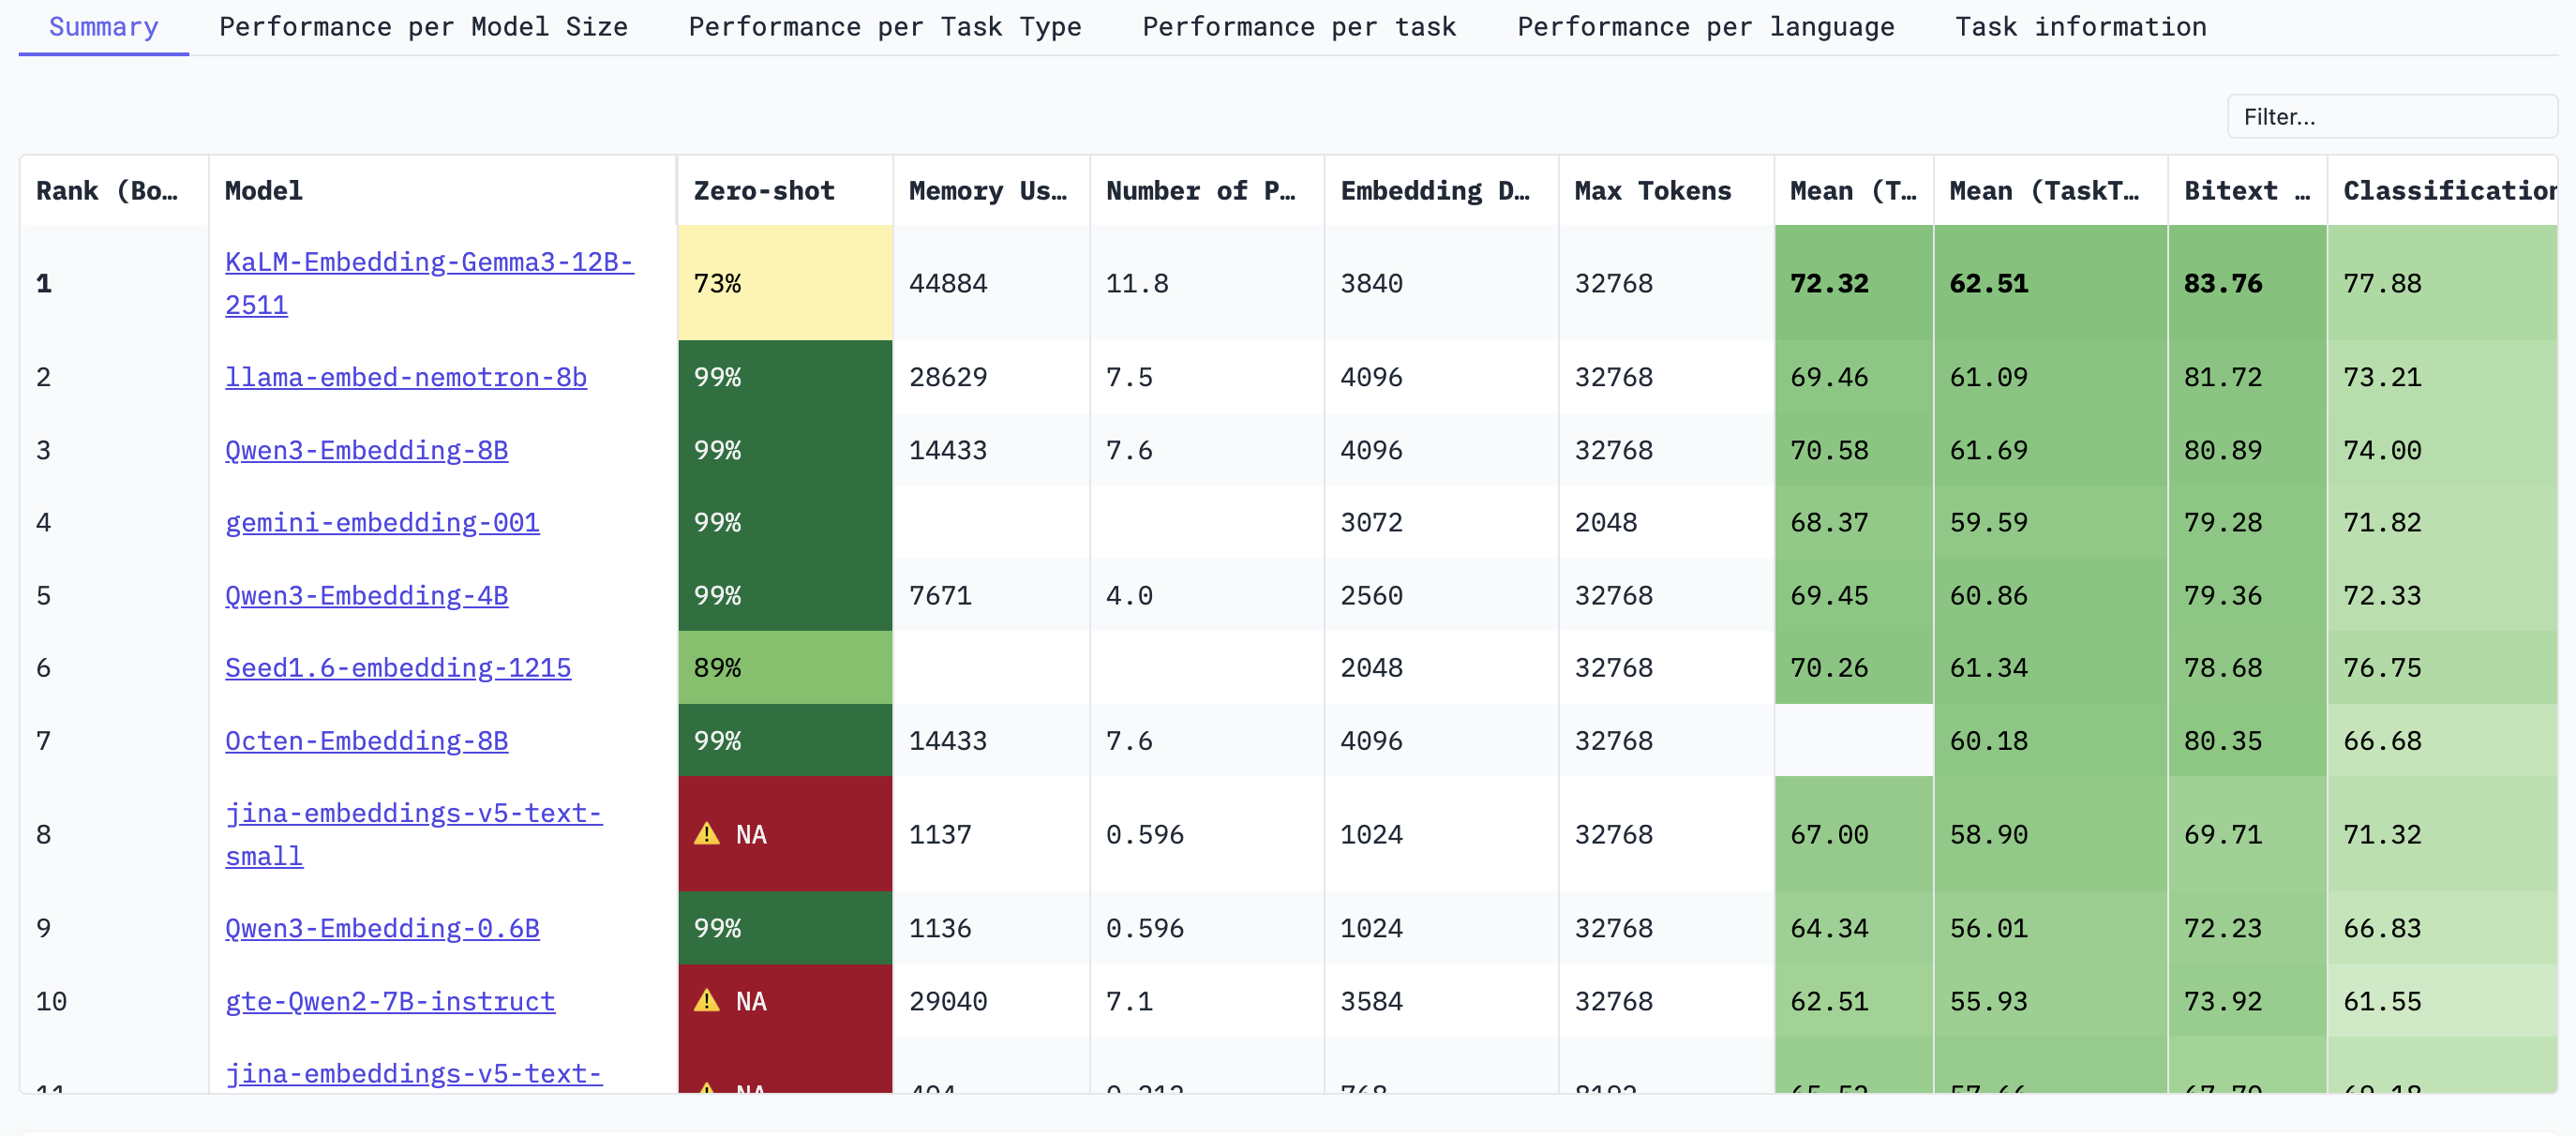

Un bon modèle d’embeddings **polyvalent** est [`gte-large`](https://huggingface.co/thenlper/gte-large).

### **Chunking documents**

Une fois le choix du modèle d’embeddings effectué, nous pouvons lui fournir les documents en entrée. Cependant, comme les documents contiennent plusieurs pages (y compris des figures et des tableaux), il nous faut une méthode pour **parser** des portions individuelles du document, compatibles avec le modèle d’embedding.

Nous savons également que le modèle d’embeddings ne peut pas traiter de texte au-delà d’une longueur de contexte fixe (**512 tokens** pour `gte-large`). Cela correspond approximativement à **400 mots** ou à environ **une page** de texte. En gardant cette contrainte à l’esprit, nous allons transformer le fichier PDF en **chunks** de texte ne dépassant pas **512 tokens**. Une autre approche consisterait à découper le fichier par **sections** du rapport (par ex., facteurs de risque, procédures judiciaires, déclarations de sécurité).

Une stratégie de *chunking* courante consiste à utiliser des **chunks de taille fixe** (telle que définie par le modèle d’embedding) et à appliquer un **léger chevauchement** entre les chunks (voir la figure ci-dessous).

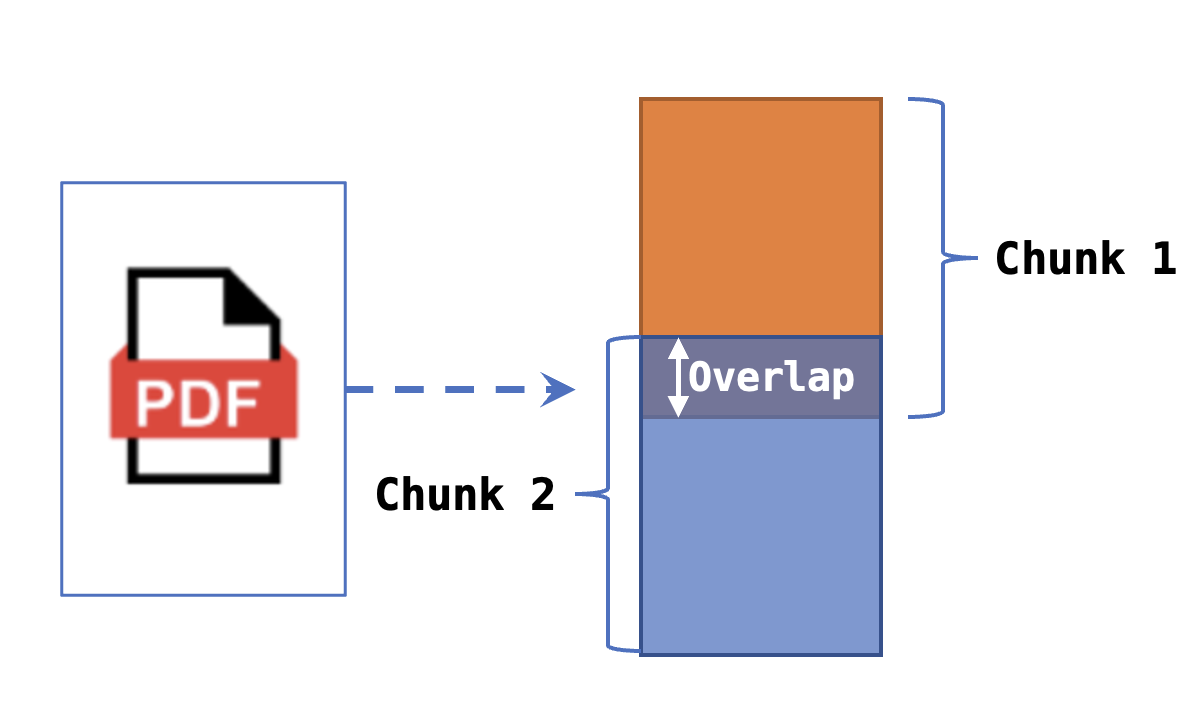

L’utilisation d’un **chevauchement (Overlap)** permet d’assurer la continuité entre les chunks et de récupérer des chunks pertinents même lorsque l’information liée à la requête se trouve soit au début, soit à la fin du chunk.

Avec un modèle d’embeddings et une stratégie de *chunking* en place, nous pouvons mettre en place un **pipeline de traitement de l’information** : chaque document est analysé (*parsed*) dans un environnement d’exécution Python, découpé en chunks, puis transmis au modèle d’embeddings. Le chunk du document ainsi que son embedding sont ensuite stockés comme une entrée dans la **base de données vectorielle**.

Notez que les bases de données vectorielles sont elles-mêmes de véritables bases de données. Elles prennent en charge toute la gamme des opérations **CRUD** (*Create, Read, Update, Delete*). Dans ce notebook, nous utiliserons les abstractions de `langchain` pour découper les documents et créer une base persistante. Reportez-vous à la [documentation Chroma DB](https://docs.trychroma.com/api-reference) pour un aperçu des opérations CRUD.

## **Step 2: Querying the Vector Database**

Une fois la **base de données vectorielle** mise en place, l’embedding généré à partir du texte de la requête est comparé à l’ensemble des embeddings de documents présents dans la base de données vectorielle. Les documents les plus similaires sont ensuite récupérés et présentés, avec la requête d’origine, dans le prompt.

Enfin, dans le prompt, nous demandons au LLM de se concentrer uniquement sur le **contexte** pour répondre à la requête de l’utilisateur. L’idée clé ici est que la requête **et** le contexte sont tous deux **injectés dynamiquement** dans le prompt.

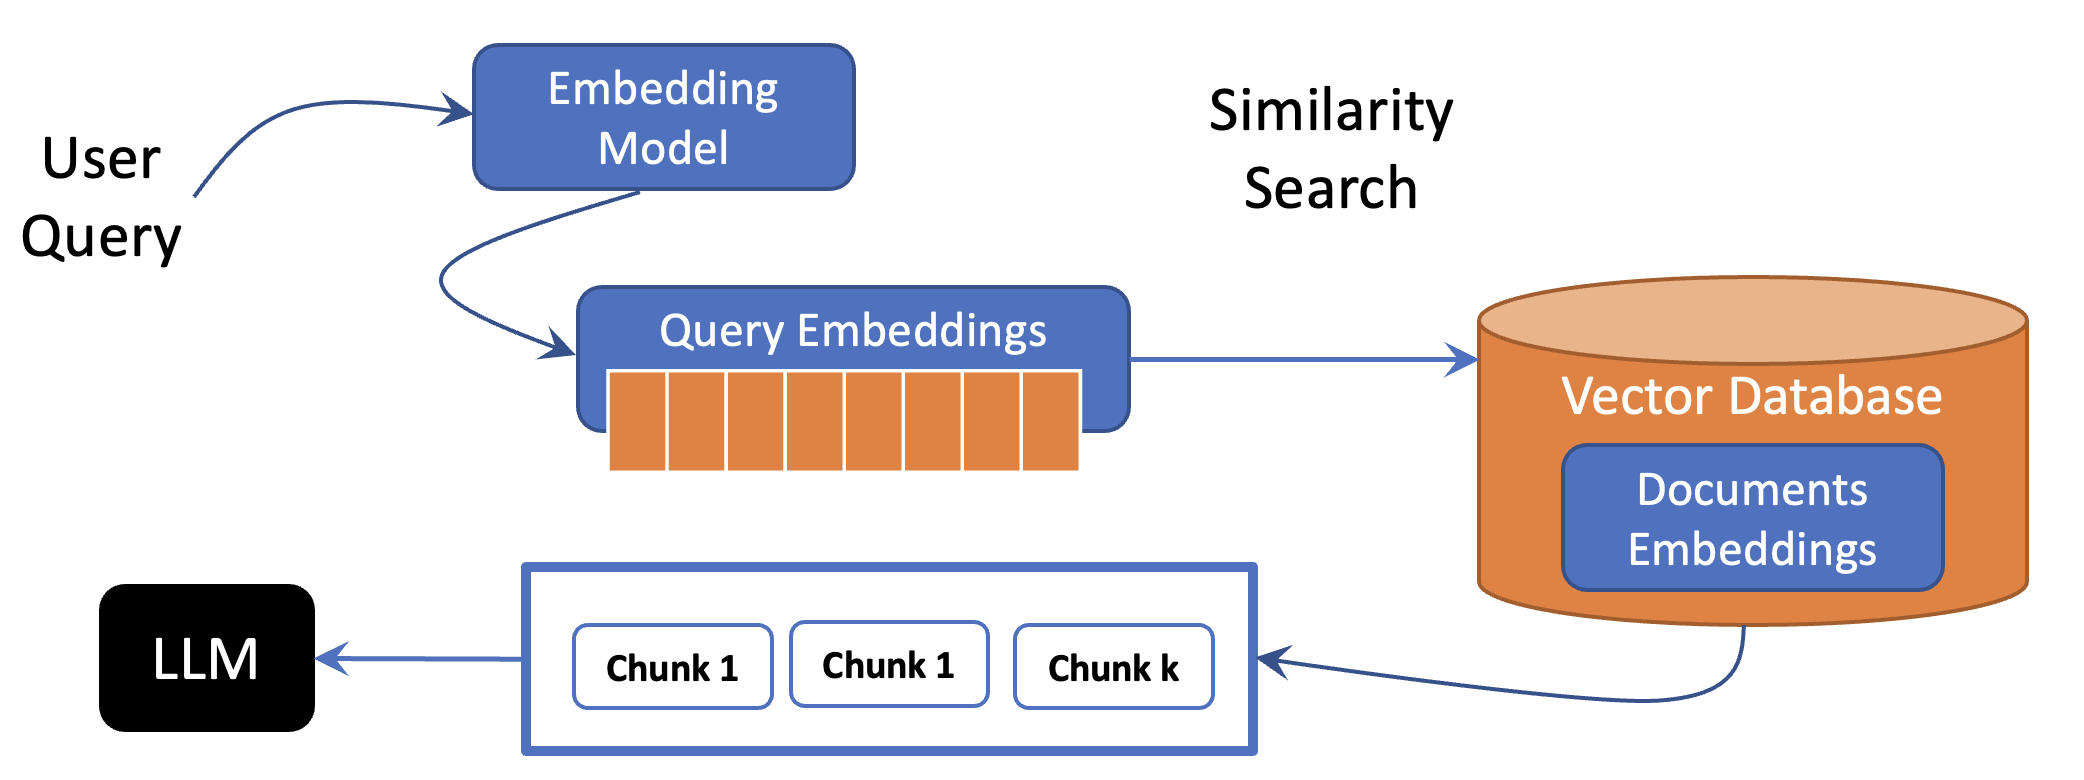

## **Problem Definition**

Obtenir des détails concernant le rapport financier de l'OCP pour l'année 2023

In [3]:
import json
import tiktoken

#import pandas as pd

from langchain_text_splitters import RecursiveCharacterTextSplitter

from langchain_community.document_loaders import PyPDFDirectoryLoader, PyPDFLoader
from langchain_community.vectorstores import Chroma

from dotenv.ipython import load_dotenv
import os

# **LLM**

In [4]:
load_dotenv(override=True)

True

In [5]:
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0
)

# **Implementing RAG**

## **1 - Loading the PDF, Chunking**

In [6]:
pdf_file = "./pdfs/Rapport Financier Annuel  OCP 2023.pdf"

In [7]:
pdf_loader = PyPDFLoader(pdf_file)

Ici, nous avons utilisé `PyPDFLoader` parce que nous travaillons avec un seul document. Supposons que nous devions traiter plusieurs documents répartis dans différents fichiers au sein d’un dossier. Dans ce cas, nous utiliserions `PyPDFDirectoryLoader` pour pointer vers ce dossier. Il chargerait alors chaque fichier, le découperait en chunks et stockerait ces chunks dans une liste. Ce processus consiste à parcourir chaque fichier du répertoire, à découper le fichier, puis à stocker les chunks.

In [8]:
from langchain_community.document_loaders import PyPDFDirectoryLoader
loader = PyPDFDirectoryLoader(path = "./pdfs")

Ici, nous avons utilisé `PyPDFDirectoryLoader` car nous travaillons avec plusieurs documents répartis dans différents fichiers au sein d’un dossier. Il charge alors chaque fichier, le découpe en segments (chunks) et stocke ces segments dans une liste. Ce processus consiste à parcourir chaque fichier du répertoire, à le fragmenter, puis à enregistrer les fragments.

S’il s’agissait d’un seul fichier, nous utiliserions alors `PyPDFLoader`.

In [9]:
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    encoding_name='o200k_base',
    chunk_size=300,
    chunk_overlap=20
)

In [10]:
chunks = loader.load_and_split(text_splitter)

In [11]:
len(chunks)

576

## **2 - Vector Store - ChromaDB, Embeddings**

In [15]:
from langchain_openai import OpenAIEmbeddings
embedding_model = OpenAIEmbeddings(model='text-embedding-ada-002')

In [16]:
vectorstore = Chroma.from_documents(
    chunks,
    embedding_model,
    collection_name="rapport_ocp_V2",
    persist_directory="./store"
)

AuthenticationError: Error code: 401 - {'error': {'message': 'Incorrect API key provided: sk-proj-********************************************************************************************************************************************************BT0A. You can find your API key at https://platform.openai.com/account/api-keys.', 'type': 'invalid_request_error', 'code': 'invalid_api_key', 'param': None}, 'status': 401}

In [ ]:
retriever = vectorstore.as_retriever(
    search_type='similarity',
    search_kwargs={'k': 5}
)

In [ ]:
retrieved_chunks=retriever.invoke("Quelles sont les performances financières de l'OCP en 2023?")

In [ ]:
print(retrieved_chunks)

[Document(metadata={'moddate': '2024-04-30T08:36:20+01:00', 'page_label': '136', 'page': 135, 'creationdate': '2024-04-29T21:13:52+01:00', 'creator': 'Nitro Pro 13 (13.32.0.623)', 'producer': 'PyPDF', 'source': 'pdfs\\Rapport Financier Annuel  OCP 2023.pdf', 'total_pages': 210}, page_content='RÉSULTATS DE L’EXERCICE 2023 \nD’OCP S.A'), Document(metadata={'moddate': '2024-04-30T08:36:20+01:00', 'creationdate': '2024-04-29T21:13:52+01:00', 'total_pages': 210, 'creator': 'Nitro Pro 13 (13.32.0.623)', 'source': 'pdfs\\Rapport Financier Annuel  OCP 2023.pdf', 'page_label': '127', 'page': 126, 'producer': 'PyPDF'}, page_content='1. Contexte de l’activité 03\n2. Activité durant l’année 2023 07\n3. Résultats de l’exercice 2023 d’OCP S.A 11'), Document(metadata={'total_pages': 210, 'source': 'pdfs\\Rapport Financier Annuel  OCP 2023.pdf', 'creator': 'Nitro Pro 13 (13.32.0.623)', 'creationdate': '2024-04-29T21:13:52+01:00', 'page': 2, 'moddate': '2024-04-30T08:36:20+01:00', 'page_label': '3', 'p

In [ ]:
print(len(retrieved_chunks))

5


## **3 - RAG Q&A**

### **Prompt Design**

In [ ]:
prompt_template = """
Answer the following question based only on provided context
The context is about OCP Annual Financial Report 2023
The context is delimited by <context> tag
The user question is delimited by <question> tag
If the answer is not found in the context, answer : JE NE SAIS PAS
<context>
 {context}
</context>
<question>
 {question}
</question>
"""

### **Retrieving the Relevant Documents**

In [ ]:
user_input = "Quelles sont les performances financières de l'OCP en 2023?"

In [ ]:
relevant_document_chunks = retriever.invoke(user_input)
context_list = [d.page_content for d in relevant_document_chunks]
context_for_query = ". ".join(context_list)

In [ ]:
context_for_query

"RÉSULTATS DE L’EXERCICE 2023 \nD’OCP S.A. 1. Contexte de l’activité 03\n2. Activité durant l’année 2023 07\n3. Résultats de l’exercice 2023 d’OCP S.A 11. Chiffres clés\nLes résultats financiers d’OCP pour les années 2022 et 2023 sont synthétisés dans les indicateurs clés présentés \nci-dessus.\nEn 2023, les performances financières de OCP ont maintenu une certaine stabilité, témoignant de la résilience du \nGroupe face à des conditions de marché fluctuantes. En effet, les fondamentaux du Groupe sont demeurés solides, \nce qui lui a permis de maintenir une position compétitive sur le marché mondial des engrais.\nIl convient de souligner que l’année 2022 a été exceptionnelle pour le Groupe OCP, cette période a été caractérisée \npar une augmentation significative du chiffre d’affaires, soutenue par la hausse des prix des produits tels que \nl’acide phosphorique et les engrais sur le marché mondial, dans ce qui pourrait être qualifié d’une année de forte \naugmentation généralisée des pr

In [ ]:
# Here the length is 10 because, earlier we have declared k=10
len(relevant_document_chunks)

5

In [ ]:
prompt = prompt_template.format(context=context_for_query, question=user_input)

In [ ]:
print(prompt)


Answer the following question based only on provided context
The context is about OCP Annual Financial Report 2023
The context is delimited by <context> tag
The user question is delimited by <question> tag
If the answer is not found in the context, answer : JE NE SAIS PAS
<context>
 RÉSULTATS DE L’EXERCICE 2023 
D’OCP S.A. 1. Contexte de l’activité 03
2. Activité durant l’année 2023 07
3. Résultats de l’exercice 2023 d’OCP S.A 11. Chiffres clés
Les résultats financiers d’OCP pour les années 2022 et 2023 sont synthétisés dans les indicateurs clés présentés 
ci-dessus.
En 2023, les performances financières de OCP ont maintenu une certaine stabilité, témoignant de la résilience du 
Groupe face à des conditions de marché fluctuantes. En effet, les fondamentaux du Groupe sont demeurés solides, 
ce qui lui a permis de maintenir une position compétitive sur le marché mondial des engrais.
Il convient de souligner que l’année 2022 a été exceptionnelle pour le Groupe OCP, cette période a été ca

In [ ]:
resp = llm.invoke(prompt)

In [ ]:
from IPython.display import Markdown

In [ ]:
print(display(Markdown(resp.content)))

En 2023, les performances financières de l'OCP ont maintenu une certaine stabilité, témoignant de la résilience du Groupe face à des conditions de marché fluctuantes. Les fondamentaux du Groupe sont demeurés solides, ce qui lui a permis de maintenir une position compétitive sur le marché mondial des engrais.

None


### **Defining the RAG function for response**




In [ ]:
def RAG(query, llm=llm, prompt_template=prompt_template):
    context_docs = retriever.invoke(query)
    context_list = [d.page_content for d in context_docs]
    context_for_query = ". ".join(context_list)
    prompt = prompt_template.format(context=context_for_query, question=query)
    resp=llm.invoke(prompt)
    return resp.content

In [ ]:
response = RAG("État du résultat global consolidé")
print(display(Markdown(response)))

Résultat global consolidé 14 187  27 629  
Dont part du Groupe 14 259  27 580  
Dont part des intérêts ne donnant pas le contrôle (72)  49.

None


In [ ]:
user_input = "j'ai fain et je veux manger quelque chose"
output = RAG(user_input)
print(output)

JE NE SAIS PAS


In [ ]:
response = RAG("Chiffre d'affaire de l'OCP en 2023")
print(display(Markdown(response)))

Le chiffre d'affaires de l'OCP en 2023 est de 81 239 323 844 Dirhams.

None


In [ ]:
response = RAG("Quelles sont les performances financières de l'OCP en 2023")
print(display(Markdown(response)))

En 2023, les performances financières de l'OCP ont maintenu une certaine stabilité, témoignant de la résilience du Groupe face à des conditions de marché fluctuantes. Les fondamentaux du Groupe sont demeurés solides, ce qui lui a permis de maintenir une position compétitive sur le marché mondial des engrais.

None


## **4 - Evaluation**

Utilisons maintenant la méthode LLM-as-a-judge pour vérifier la qualité du système RAG selon deux paramètres : la récupération (retrieval) et la génération (generation). Nous illustrons cette évaluation à partir des réponses générées à la question de la section précédente.

Nous utilisons le même modèle pour l’évaluation ; en d’autres termes, ici le LLM s’auto-évalue en notant la qualité de sa propre performance dans la tâche.

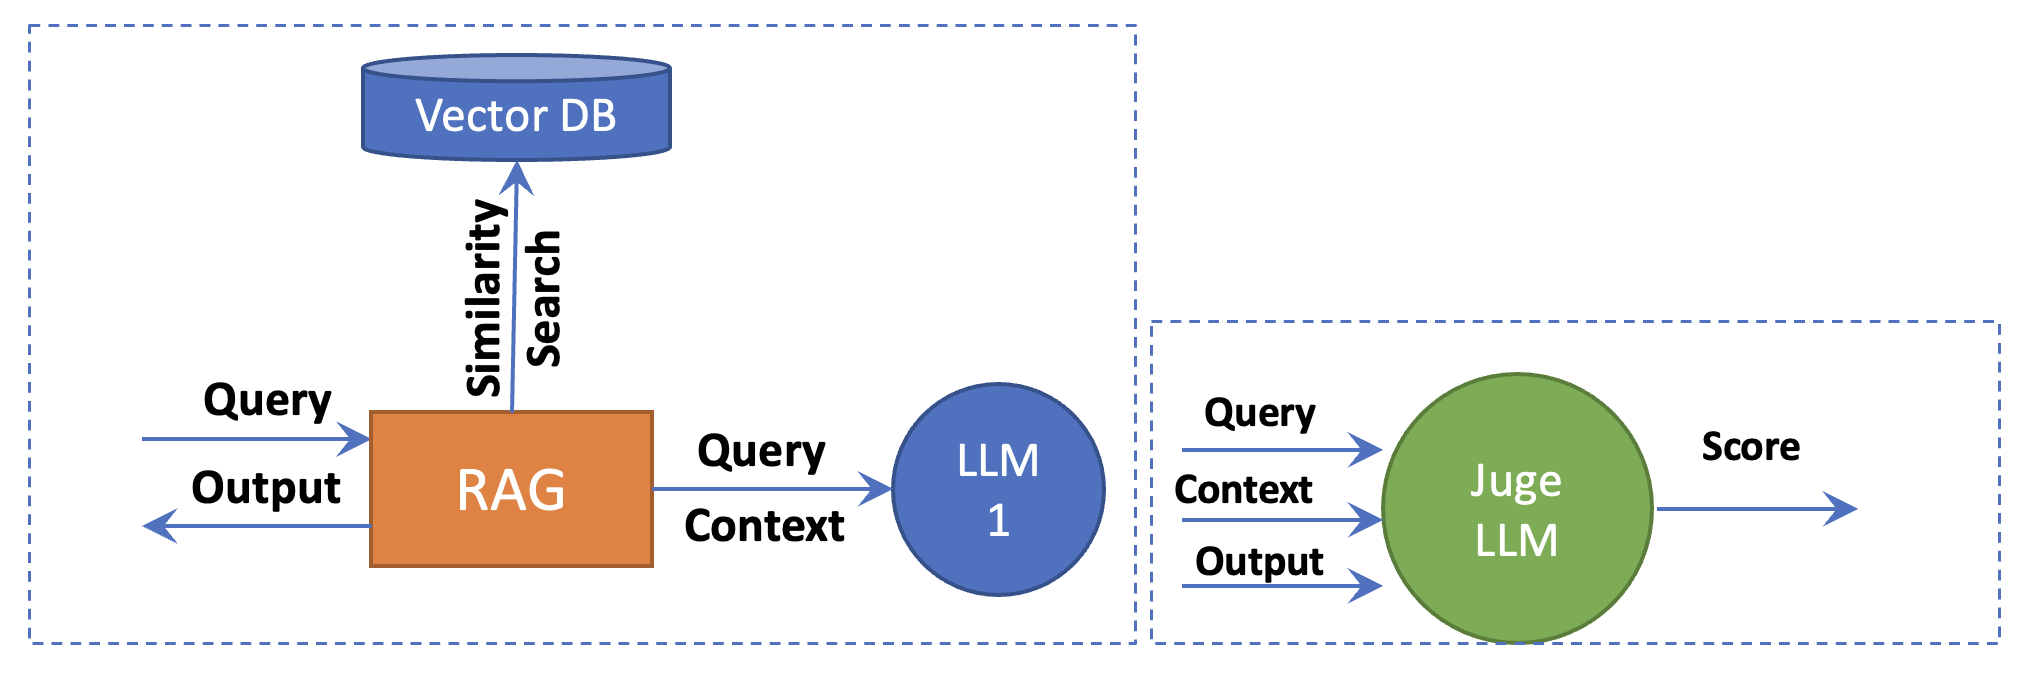

In [ ]:
user_input ="État du résultat global consolidé"

In [ ]:
relevant_document_chunks = retriever.invoke(user_input)
context_list = [d.page_content for d in relevant_document_chunks]
context_for_query = ". ".join(context_list)

In [ ]:
user_message_template = """
 ###Question
 {question}
 ###Context
 {context}
 ###Answer
 {answer}
"""

In [ ]:
# Default answer for an RAG query
answer = RAG(user_input)
print(display(Markdown(answer)))

Résultat global consolidé 14 187  27 629  
Dont part du Groupe 14 259  27 580  
Dont part des intérêts ne donnant pas le contrôle (72)  49.

None


### 1. Groundness

In [ ]:
groundedness_rater_system_message="""
Vous êtes chargé d’évaluer des réponses générées par une IA à des questions posées par des utilisateurs.
On vous présentera une question, le contexte utilisé par le système d’IA pour générer la réponse, ainsi qu’une réponse générée par l’IA à la question.

Dans l’entrée, la question commencera par ###Question, le contexte commencera par ###Context, et la réponse générée par l’IA commencera par ###Answer.

Critères d’évaluation :
La tâche consiste à juger dans quelle mesure la réponse respecte la métrique.

1 — La métrique n’est pas respectée du tout
2 — La métrique n’est respectée que dans une mesure limitée
3 — La métrique est respectée dans une bonne mesure
4 — La métrique est respectée en grande partie
5 — La métrique est entièrement respectée

Métrique :
La réponse doit être dérivée uniquement des informations présentées dans le contexte.

Instructions :

Écrivez d’abord les étapes nécessaires pour évaluer la réponse selon la métrique.
Donnez une explication étape par étape indiquant si la réponse respecte la métrique, en considérant la question et le contexte comme entrées.
Évaluez ensuite dans quelle mesure la métrique est respectée.
Utilisez les informations précédentes pour noter la réponse selon les critères d’évaluation et attribuer un score.
"""

In [ ]:
groundness_checker = ChatOpenAI(
    model="gpt-4o",
    temperature=0
)

In [ ]:
def evaluate(system_message,user_message_template, question, model=groundness_checker):
    retrieved_chunks=retriever.invoke(question)
    context_list = [d.page_content for d in retrieved_chunks]
    context = ". ".join(context_list)
    answer = RAG(question)
    prompt = f"""
     {system_message}\n
     USER:
     {user_message_template.format(question=question, context=context, answer=answer)}
    """
    juge_response= model.invoke(prompt)
    return juge_response.content


In [ ]:
resp=evaluate(groundedness_rater_system_message, user_message_template, user_input)

NameError: name 'evaluate' is not defined

In [ ]:
print(display(Markdown(resp)))

NameError: name 'Markdown' is not defined

# **Conclusion**
- Dans ce notebook, nous avons appris à créer une application basée sur la génération augmentée par récupération (Retrieval-Augmented Generation, RAG), capable d’effectuer des questions-réponses sur des articles de recherche afin de récupérer des informations plus rapidement, plus efficacement et avec davantage de précision.